# Bitácora 00 · Bienvenida

**Especialización en Inteligencia Artificial · UPTC**  
Módulo: Aprendizaje por Refuerzo y Sistemas de Recomendación

---

### Cuándo se usa este cuaderno

Después de **P1** y de **P5 · Trabajar con VS Code y la terminal**, y antes de la
sesión 1 del viernes. Se recorre entero una vez, de arriba abajo.

**No se entrega y no se califica.**

### Qué hay que entender hoy, y qué no

Hoy hay que entender **una sola cosa**, y es la regla del curso:

> El algoritmo vive en el paquete. El notebook es la bitácora.

Fíjese en que aquí **no se define nada**. Todo se importa de `rlrs`, que vive en
`src/rlrs/` y tiene sus pruebas en `tests/`. Lo que se hace aquí es mirar, medir
y contar. Eso es lo que hay que ver funcionando.

**Lo que el cuaderno calcula todavía no hay que entenderlo.** Va a aparecer
vocabulario que aún no hemos visto: iteración de valor, gamma, política óptima.
Es normal y es a propósito: son exactamente los contenidos del viernes. Hoy basta
con ejecutar y comprobar que sale algo. El viernes volverá a ver estos mismos
números, y entonces sabrá de dónde salen.

Si algo falla al ejecutarlo, **P5** lo explica paso a paso, con capturas.


In [1]:
from rlrs import GridWorld, RandomPolicy, GreedyTabularPolicy, value_iteration, evaluate
import numpy as np
import matplotlib.pyplot as plt

print('Todo importado correctamente.')


Todo importado correctamente.


## 1. El entorno

Una rejilla 4×5. La meta vale `+1`, la trampa `-1`, y cada paso cuesta `-0.04`
para que al agente le convenga no dar vueltas. Con `noise=0.2`, una de cada
cinco veces el agente se desvía: el suelo resbala.


In [2]:
env = GridWorld()
print(f'{env.n_states} estados · {env.n_actions} acciones · ruido {env.noise}')
print('Muros:', sorted(env.walls))
print('Terminales:', env.terminals)


20 estados · 4 acciones · ruido 0.2
Muros: [(1, 1), (2, 3)]
Terminales: {(0, 4): 1.0, (1, 4): -1.0}


### El modelo del entorno

`transitions(pos, accion)` devuelve la distribución `P(s' | s, a)`.
Esto es lo que la programación dinámica puede usar y lo que los métodos
sin modelo (Q-learning, SARSA) tienen prohibido mirar.


In [3]:
for accion, nombre in enumerate(['arriba','derecha','abajo','izquierda']):
    destinos = env.transitions((3, 1), accion)
    print(f'{nombre:<10}', [(pos, round(p, 2)) for pos, p in destinos])


arriba     [((2, 1), 0.8), ((3, 0), 0.1), ((3, 2), 0.1)]
derecha    [((2, 1), 0.1), ((3, 1), 0.1), ((3, 2), 0.8)]
abajo      [((3, 0), 0.1), ((3, 1), 0.8), ((3, 2), 0.1)]
izquierda  [((2, 1), 0.1), ((3, 0), 0.8), ((3, 1), 0.1)]


> **A partir de aquí, mire y siga.** Lo que viene es el contenido de la sesión 1.
> Hoy no hay que entenderlo: hay que comprobar que se ejecuta y que devuelve
> una rejilla con números y flechas.


## 2. Resolverlo con iteración de valor

Aplicamos la ecuación de optimalidad de Bellman hasta que deja de cambiar:

$$V(s) \leftarrow \max_a \sum_{s'} P(s'|s,a)\,[\,R(s') + \gamma V(s')\,]$$


In [4]:
valores, politica, barridos = value_iteration(env, gamma=0.9)
print(f'Convergió en {barridos} barridos.\n')
print(env.render_values(valores, politica))


Convergió en 35 barridos.

+0.48>  +0.61>  +0.75>  +0.93>   +1    
+0.37^    ###   +0.61^  +0.59^   -1    
+0.28^  +0.36>  +0.47^    ###   +0.10v 
+0.21^  +0.27^  +0.35^  +0.26<  +0.17< 


### Qué pasa si el agente se vuelve miope

Baja `gamma` y vuelve a mirar la fila de abajo. Con un descuento pequeño,
la meta queda tan lejos que deja de compensar el viaje: los valores se
vuelven negativos.

**Ejercicio.** Prueba con `gamma` = 0.55, 0.7, 0.9 y 0.99. ¿Cómo cambia el
número de barridos? ¿Por qué?


In [5]:
for g in (0.55, 0.7, 0.9, 0.99):
    v, _, n = value_iteration(env, gamma=g)
    esquina = v[env.state_index((3, 0))]
    print(f'gamma={g:<5}  barridos={n:>4}  V(esquina inferior izquierda)={esquina:+.3f}')


gamma=0.55   barridos=  21  V(esquina inferior izquierda)=-0.074
gamma=0.7    barridos=  27  V(esquina inferior izquierda)=-0.055
gamma=0.9    barridos=  35  V(esquina inferior izquierda)=+0.206
gamma=0.99   barridos=  51  V(esquina inferior izquierda)=+0.601


El número de barridos aumenta siempre y cuando el valor de gamma se acerca a 1 porque, al ser un agente con mayor visión a largo plazo, este debe expandir la información de la recompensa desde la meta hacia estados más lejanos a través, de un mayor número de iteraciones para lograr llegar a la convergencia. Sin embargo, cuando gamma toma valores pequeños, el agente es miope y este solo va a priorizar recompensas que son inmediatas, lo que hace que el valor de los estados distantes de la meta bajen rápidamente al aplicar el factor de descuento, haciendo que el algoritmo converja mucho más rápido, aunque nos de una estimación negativa.

## 3. Medir, no confiar

Una corrida no es un resultado. `evaluate` ejecuta muchos episodios con
semillas explícitas y devuelve la media **con su intervalo de confianza**.

La comparación contra la política aleatoria es la comprobación de cordura
del arnés: si la óptima no gana, el problema está en la evaluación.


In [7]:
optima = evaluate(env, GreedyTabularPolicy(politica, name='optima'), episodes=300)
azar   = evaluate(env, RandomPolicy(env.n_actions, seed=0), episodes=300)

for r in (optima, azar):
    print(r)


optima         retorno +0.636 [+0.603, +0.670]  exito 98.0%  pasos   9.1
aleatoria      retorno -2.520 [-2.679, -2.361]  exito 25.7%  pasos  56.8


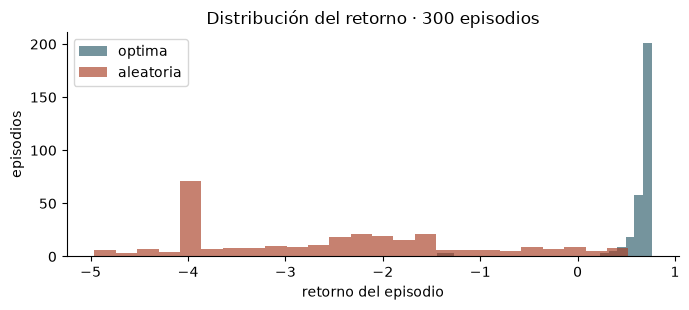

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2))
for r, color in ((optima, '#2C5B69'), (azar, '#A83E24')):
    ax.hist(r.returns, bins=25, alpha=.65, label=r.policy_name, color=color)
ax.set_xlabel('retorno del episodio'); ax.set_ylabel('episodios')
ax.set_title('Distribución del retorno · 300 episodios')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


---

## Tu turno · opcional, no se entrega

### Ahora, antes de la sesión 1

Dos exploraciones sobre **cómo se mide**, que no necesitan saber nada de
aprendizaje por refuerzo.

1. Evalúe la política óptima con `episodes=30`, luego con `300` y luego con `3000`.
   Mire cómo cambia el ancho del intervalo de confianza. ¿A qué velocidad se estrecha?
2. Evalúe dos veces la **misma** política cambiando `base_seed`. ¿Sale el mismo número?
   ¿Se solapan los intervalos? ¿Qué habría que reportar entonces?

Esa idea, que un número sin su intervalo no es un resultado, es la que gobierna
todas las mediciones del módulo.

### Después de la sesión 1

3. Escriba una política heurística, «ve siempre a la derecha, y si no puedes, sube»,
   y compárela con la óptima y con la aleatoria.

**Importante para el punto 3.** Esa política es código reutilizable, así que va en
`src/rlrs/policies.py` con su prueba en `tests/`, no en este cuaderno. Aquí solo se
importa y se mide. Es exactamente la regla que este cuaderno viene a demostrar.

> Las preguntas sobre $\gamma$, el ruido y el coste por paso, con predicción escrita
> y entrega, están en el **Laboratorio 1**. Aquí no hace falta adelantarlas.


**Subir el ruido a 0.5**

Aquí inicializamos nuestro entorno. Y al subir el ruido, el agente se vuelve mucho más dificil al moverse. Cerca de la trampa, la política cambia para ser más conservadora. Si el suelo resbala tanto, el agente preferirá dar un rodeo más largo pero seguro, en lugar de arriesgarse a pasar cerca de la trampa donde un deslizamiento accidental significaría el fin del epi

In [9]:
env_ruidoso = GridWorld(noise=0.5)
valores, politica, barridos = value_iteration(env_ruidoso, gamma=0.9)
print(env_ruidoso.render_values(valores, politica))

+0.13>  +0.30>  +0.45>  +0.72>   +1    
+0.04^    ###   +0.31^  +0.34<   -1    
-0.03^  +0.01>  +0.13^    ###   -0.20v 
-0.08^  -0.06>  -0.01^  -0.08<  -0.16< 


**step_reward a 0.0**

Lo que hace es que la cantidad de pasos promedio aumenta significativamente, y es que antes el agente buscaba el camino más corto para minimizar el costo acumulado, es que el agente se vuelve indiferente a dar vueltas innecesarias, ya que llegar temprano le reporta el mismo beneficio.

In [10]:
env_sin_costo = GridWorld(step_reward=0.0)
valores, politica, barridos = value_iteration(env_sin_costo, gamma=0.9)
print(env_sin_costo.render_values(valores, politica))

+0.62>  +0.72>  +0.82>  +0.94>   +1    
+0.55^    ###   +0.71^  +0.66<   -1    
+0.48^  +0.53>  +0.62^    ###   +0.35v 
+0.43^  +0.47^  +0.53^  +0.46<  +0.40< 
